In [270]:
import random
import random
import numpy as np
import pandas as pd
from dateutil.rrule import weekday
import seaborn as sns
from scipy.linalg import solve
from scipy.ndimage import label
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform



<h1>Discriminant analysis: LDA, QDA </h1>
<h2> abstraction of the problem</h2>

A classification problem aims to model the relationship between an input x and a categorical output y. In this project, the Capital Bikeshare bikes is trying to understand if an increase in number of currently available bikes is necessary or not.

<h1>Generative models</h1>
<p>A generative model, shows how an input X and an outpu Y is generated via P(y|x)</p>
$$P(A \mid B) = \frac{ P(B \mid A) P(A) }{ P(B) }$$
 A generative model calssifier is based on the following conditional probability, where y=m occures if X is met in Baye's theorem:
 $$P(y=m \mid x) = \frac{ P(y=m) P(x\mid y=m) }{ \sum P(x\mid m) P(m) }$$

 


<h1>Normalization</h1>
<p>LDA is a generative classifier model assumes the data is normaly distributed. This requires our data to be normalized since many of the features, including(Temp, Dew, Humidity, Windspeed, Cloudcover, Visibility) have a wide range of values. In addition, due to lack of variability and meaningfullness, we droped the Snow and Snow Depth.</p> We have chosen to procceed with two methods</p>

<ul>
<li> Z-score
<li> Min-Max
</ul>
<h1> Z-score </h1>
<p> The standard deviation shows how much the data deviates from the mean. a small standar deviation makes the data less spread out around the mean.</p>

LDA model assume all data follow the gausain distribution, meaning they don't varry from eachother. In addition, LDA, unlike QDA, assumes features have the same mean. Due to these requirments, in the event we notice our data's variance is too large, we need to perfrom standarzation.

In [271]:
df=pd.read_csv('training_data_vt2025.csv')
df

,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility,increase_stock
0,5,5,1,0,0,0,-7.2,-15.0,53.68,0.000,0,0.0,16.3,31.6,16.0,low_bike_demand
1,21,4,1,0,1,0,-1.3,-12.8,40.97,0.000,0,0.0,23.9,85.7,16.0,low_bike_demand
2,21,3,8,0,1,1,26.9,21.8,73.39,0.000,0,0.0,0.0,81.1,16.0,low_bike_demand
3,1,6,1,0,0,0,3.1,-4.0,59.74,0.000,0,0.0,19.2,0.0,16.0,low_bike_demand
4,17,0,3,0,1,0,11.7,-11.4,18.71,0.000,0,0.0,10.5,44.6,16.0,low_bike_demand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,3,5,6,0,0,1,21.5,19.4,87.68,0.000,0,0.0,10.6,24.4,16.0,low_bike_demand
1596,14,0,6,0,1,1,23.2,20.1,82.43,2.217,0,0.0,9.8,92.1,10.4,low_bike_demand
1597,13,0,3,0,1,1,13.9,-2.2,32.93,0.000,0,2.0,18.2,79.3,16.0,low_bike_demand
1598,14,5,3,0,0,1,11.7,-9.3,22.09,0.000,0,0.0,5.8,24.4,16.0,high_bike_demand


In [272]:
data.describe()

,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility
count,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.0,1600.000000,1600.000000,1600.000000,1600.000000
mean,11.37125,3.022500,6.468750,0.033125,0.710000,0.64375,15.210313,7.750750,63.927844,0.122042,0.0,0.042713,13.082500,64.322375,15.344125
std,6.94837,2.012965,3.454741,0.179019,0.453904,0.47904,9.264785,10.026459,19.079419,0.920600,0.0,0.421198,7.756652,32.748869,2.323737
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.00000,-9.100000,-18.400000,15.850000,0.000000,0.0,0.000000,0.000000,0.000000,0.100000
25%,5.00000,1.000000,3.000000,0.000000,0.000000,0.00000,7.700000,-0.800000,47.845000,0.000000,0.0,0.000000,7.500000,28.800000,16.000000
50%,12.00000,3.000000,6.000000,0.000000,1.000000,1.00000,15.500000,8.300000,65.175000,0.000000,0.0,0.000000,12.300000,79.300000,16.000000
75%,17.00000,5.000000,9.000000,0.000000,1.000000,1.00000,23.200000,16.800000,79.955000,0.000000,0.0,0.000000,17.600000,92.800000,16.000000
max,23.00000,6.000000,12.000000,1.000000,1.000000,1.00000,35.600000,24.300000,99.890000,25.871000,0.0,6.710000,43.800000,100.000000,16.000000


<h1>Model Tuning </h1>
<p> A machine learning model learns from training exisitng data to fir the model parameters. However there are other parameters involved in trainign a model called, Hyperparameters. They are external configuraiton variables that are used to manage models, like how fast it should learn or its complexity. Hyperparameter tuning helps a model improve its accuracy and prevents overfitting which can be beneficial for LDA. We have used two Hyperparameter Tuning techniques in this analysis </p>
<ul>
<li>GridSearch: Tests all possible hyperparameters to find the optimal one, However it is computationaly expensive but accurate.
<li>RandomizeSearch:Randomly sample hyperparameter to find an optimal combination. Faster but it is possible to miss a combination
</ul>

In [273]:
# all 1600 data
tcp=df.drop(['increase_stock'],axis=1)
tcp_y=df['increase_stock']
tcp_y

0        low_bike_demand
1        low_bike_demand
2        low_bike_demand
3        low_bike_demand
4        low_bike_demand
              ...       
1595     low_bike_demand
1596     low_bike_demand
1597     low_bike_demand
1598    high_bike_demand
1599     low_bike_demand
Name: increase_stock, Length: 1600, dtype: object

In [274]:
#GridSearch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

# Define LDA and parameter grid
lda = LinearDiscriminantAnalysis()
param_grid = {
    'solver': [ 'lsqr','eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]  # Only used for 'lsqr' and 'eigen'
}

# Run GridSearchCV
grid_search = GridSearchCV(lda, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(tcp, tcp_y)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'shrinkage': 'auto', 'solver': 'lsqr'}
Best Accuracy: 0.8462500000000001


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Loca

In [275]:
#RandomSearch


# Define LDA model
lda = LinearDiscriminantAnalysis()

# Define correct hyperparameter distribution
param_dist = {
    "solver": ['lsqr', 'eigen'],  # 'svd' does not support shrinkage
    "shrinkage": uniform(0, 1),  # Random float between 0 and 1
}

# Run RandomizedSearchCV
lda_cv = RandomizedSearchCV(lda, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
lda_cv.fit(tcp, tcp_y)

# Print best parameters and score
print("Tuned LDA Parameters: {}".format(lda_cv.best_params_))
print("Best score is {}".format(lda_cv.best_score_))


Tuned LDA Parameters: {'shrinkage': np.float64(0.3745401188473625), 'solver': 'lsqr'}
Best score is 0.8412499999999999


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2896\2539823481.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


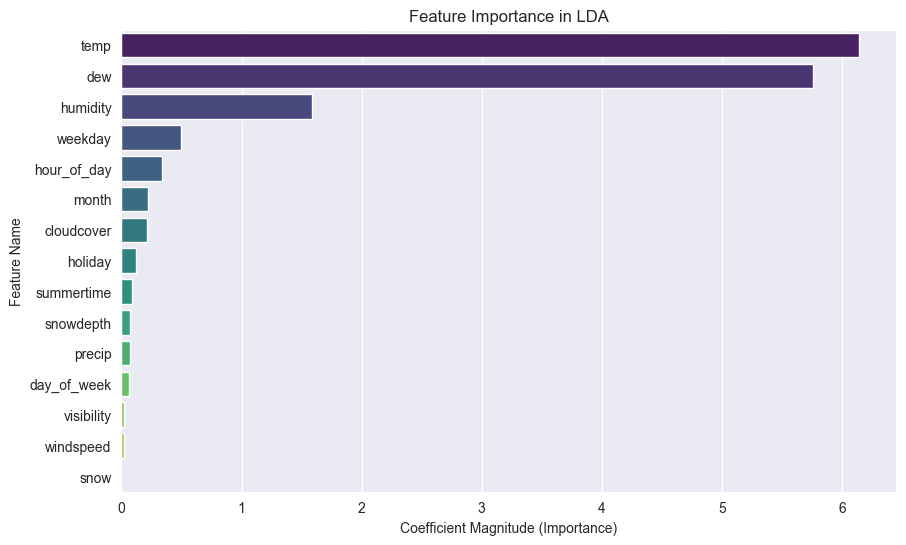

In [276]:


# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(tcp, tcp_y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Get feature importance (absolute values of LDA coefficients)
feature_importance = np.abs(lda.coef_[0])  # LDA coefficients
feature_names = tcp.columns  # Feature names

# Create DataFrame for plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.xlabel('Coefficient Magnitude (Importance)')
plt.ylabel('Feature Name')
plt.title('Feature Importance in LDA')
plt.show()


<h1>Seperating Varibales into train and test</h1>

In [277]:
df['month'].shape[0]

1600

In [278]:
np.random.seed(0)
trainI=np.random.choice(df['month'].shape[0],size=1200,replace=False)
index=df.index.isin(trainI)
train=df.iloc[index]
test=df.iloc[~index]
train.shape[0]
train
tcp=train.drop(['increase_stock'],axis=1)
tcp
tcp_y=train['increase_stock']
tcp_y

0        low_bike_demand
1        low_bike_demand
2        low_bike_demand
3        low_bike_demand
4        low_bike_demand
              ...       
1594     low_bike_demand
1596     low_bike_demand
1597     low_bike_demand
1598    high_bike_demand
1599     low_bike_demand
Name: increase_stock, Length: 1200, dtype: object

<h1>Independent and Dependent Variables</h1>



In [279]:
features = ['hour_of_day','day_of_week','month','weekday','temp', 'dew', 'humidity', 'windspeed', 'cloudcover', 'visibility']

X_train=train[features]
y_train=train['increase_stock']
X_test=test[features]
y_test=test['increase_stock']
#Before standarzation
X_test.describe()

,hour_of_day,day_of_week,month,weekday,temp,dew,humidity,windspeed,cloudcover,visibility
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,11.682500,3.075000,6.557500,0.720000,15.010250,7.594250,63.995100,13.140500,64.497750,15.317500
std,7.034943,1.966989,3.517474,0.449561,9.009923,9.788717,18.771214,7.964077,33.498632,2.461105
min,0.000000,0.000000,1.000000,0.000000,-3.900000,-17.200000,17.850000,0.000000,0.000000,0.100000
25%,6.000000,1.000000,3.750000,0.000000,7.650000,-0.825000,49.205000,7.400000,26.400000,16.000000
50%,12.000000,3.000000,6.000000,1.000000,14.300000,7.900000,65.025000,12.550000,79.300000,16.000000
75%,17.000000,5.000000,10.000000,1.000000,22.800000,16.375000,78.775000,17.450000,96.000000,16.000000
max,23.000000,6.000000,12.000000,1.000000,35.600000,24.300000,99.890000,43.800000,100.000000,16.000000


<h1>Train and Test Sets</h1>

The X dataset has our ten features and the y dataset has our dependent variable which is increase stock or decrease stock. We
can not split our data into a train and test set. The code is below.

The training data set consist of 70% and the test data set is consist of 30% of our actual data. 

In [280]:
X_train.describe()

,hour_of_day,day_of_week,month,weekday,temp,dew,humidity,windspeed,cloudcover,visibility
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,11.267500,3.005000,6.439167,0.706667,15.277000,7.802917,63.905425,13.063167,64.263917,15.353000
std,6.919116,2.028564,3.434549,0.455480,9.350932,10.107943,19.188745,7.689550,32.509079,2.277106
min,0.000000,0.000000,1.000000,0.000000,-9.100000,-18.400000,15.850000,0.000000,0.000000,0.100000
25%,5.000000,1.000000,3.000000,0.000000,7.800000,-0.700000,47.560000,7.500000,32.475000,16.000000
50%,11.000000,3.000000,6.000000,1.000000,15.750000,8.400000,65.330000,12.250000,79.300000,16.000000
75%,17.000000,5.000000,9.000000,1.000000,23.200000,17.100000,80.275000,17.600000,91.800000,16.000000
max,23.000000,6.000000,12.000000,1.000000,35.500000,24.300000,99.890000,40.600000,100.000000,16.000000


In [281]:

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)


In [282]:
X_train=pd.DataFrame(X_train)
X_test=pd.DataFrame(X_test)

In [283]:
X_train.describe()


,0,1,2,3,4,5,6,7,8,9
count,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03
mean,-8.881784e-18,5.329071e-17,-8.585725e-17,-4.070818e-17,-1.117625e-16,2.072416e-17,3.256654e-16,1.206442e-16,2.131628e-16,-6.631732e-16
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-1.629138e+00,-1.481961e+00,-1.584323e+00,-1.552125e+00,-2.607993e+00,-2.593390e+00,-2.505399e+00,-1.699529e+00,-1.977623e+00,-6.701207e+00
25%,-9.062014e-01,-9.887961e-01,-1.001762e+00,-1.552125e+00,-7.999328e-01,-8.415621e-01,-8.521787e-01,-7.237726e-01,-9.782550e-01,2.842510e-01
50%,-3.867712e-02,-2.465826e-03,-1.279206e-01,6.442782e-01,5.060428e-02,5.909534e-02,7.427109e-02,-1.057937e-01,4.627123e-01,2.842510e-01
75%,8.288472e-01,9.838645e-01,7.459206e-01,6.442782e-01,8.476484e-01,9.201634e-01,8.534378e-01,5.902458e-01,8.473806e-01,2.842510e-01
max,1.696371e+00,1.477030e+00,1.619762e+00,6.442782e-01,2.163574e+00,1.632772e+00,1.876078e+00,3.582565e+00,1.099723e+00,2.842510e-01


<h1>Training On given data</h1>

### Formula(LDA)
To calculate LDA, we will be using the logic behind beyers theorom, where we need Two parameters:
1- Prior class probabilities  
2- The conditional probability density 


To implement the LDA, we need to know the bayes rule. And it requires to implement probability distribution function. Basic notation is like this:
$$
g_m(x) = \frac{\pi_m f_m(x)}{\sum_{m=1}^{M} \pi_m f_m(x)}
$$
$${\pi_m =\frac{ n_m}{n}}$$


$$ f_m(x) = \frac{1}{\vert 2 \pi \Sigma \vert^{\frac{1}{2}}} \text{exp} \big( -\frac{1}{2} (x - \mu)^T (\Sigma)^{-1} (x - \mu)\big) $$


In our case, we either have the increase or decrease so our m is either 0 or 1, which by putting them in the formula mentioned above, we reach the following probability distribution:

$$ f(x \vert y=0) = \frac{1}{\vert 2 \pi \Sigma^{(0)} \vert^{\frac{1}{2}}} \text{exp} \big( -\frac{1}{2} (x - \mu^{(0)})^T (\Sigma^{(0)})^{-1} (x - \mu^{(0)})\big)\\
$$

$$f(x \vert y=1) = \frac{1}{\vert 2 \pi \Sigma^{(1)} \vert^{\frac{1}{2}}} \text{exp} \big( -\frac{1}{2} (x - \mu^{(1)})^T (\Sigma^{(1)})^{-1} (x - \mu^{(1)})\big) $$

The model was build to maximize multivariate guassian distribution, meaning if we have multiple features, it chooses the best guasian distribution according to them, However, with one difference :

1- LDA assumes all features have the samve covariance, their measurements might be different but they are all centered around the same area

2- QDA shows no assumption between datas, making it a more realistic but complexer model

Maximizing the mentioned formula will result in

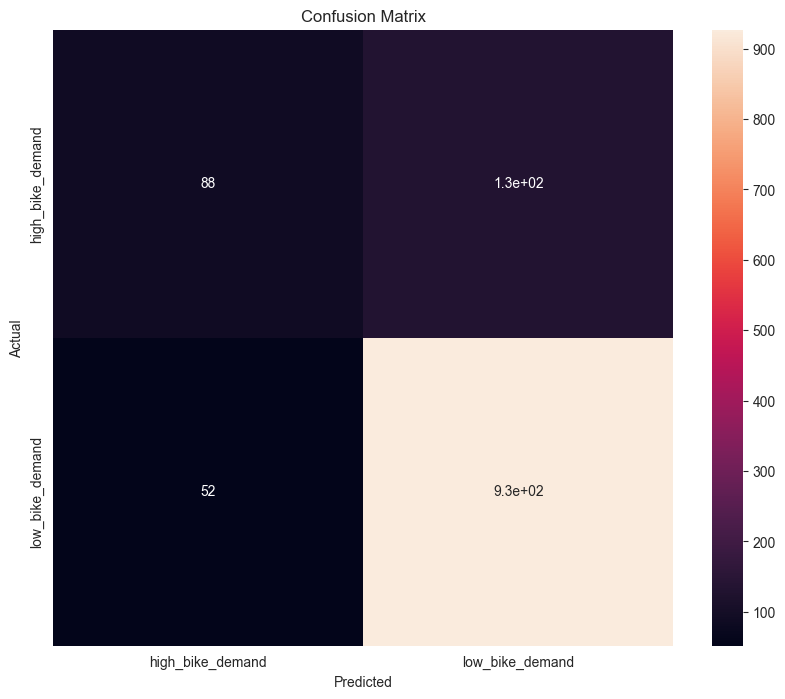

In [285]:
model=LinearDiscriminantAnalysis(solver='lsqr',shrinkage="auto") 

model.fit(X_train,y_train)
predictions=model.predict(X_test)
model.predict(X_test)
cm=pd.crosstab(y_train,model.predict(X_train))

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

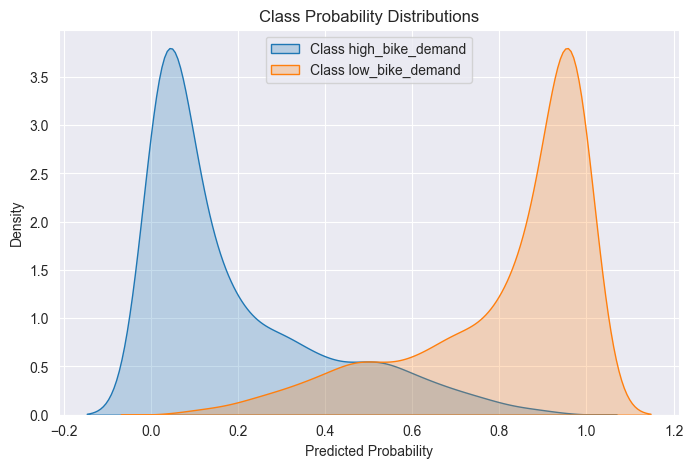

In [286]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get predicted probabilities
y_prob = model.predict_proba(X_train)

# Convert to a DataFrame for easier plotting
df = pd.DataFrame(y_prob, columns=model.classes_)

# Plot density distribution of predicted probabilities
plt.figure(figsize=(8, 5))
for c in model.classes_:
    sns.kdeplot(df[c], label=f'Class {c}', fill=True)

plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Class Probability Distributions')
plt.legend()
plt.show()


In [287]:
print('Accuracy:',accuracy_score(y_test, model.predict(X_test)))
X_train

Accuracy: 0.86


,0,1,2,3,4,5,6,7,8,9
0,-0.906201,0.983864,-1.584323,-1.552125,-2.404720,-2.256881,-0.533109,0.421115,-1.005182,0.284251
1,1.407197,0.490699,-1.584323,0.644278,-1.773503,-2.039140,-1.195752,1.409881,0.659663,0.284251
2,1.407197,-0.002466,0.454640,0.644278,1.243496,1.385338,0.494484,-1.699529,0.518105,0.284251
3,-1.484551,1.477030,-1.584323,-1.552125,-1.302766,-1.168174,-0.217167,0.798407,-1.977623,0.284251
4,0.828847,-1.481961,-1.001762,0.644278,-0.382688,-1.900577,-2.356291,-0.333470,-0.605127,0.284251
...,...,...,...,...,...,...,...,...,...,...
1195,1.551784,1.477030,0.745921,-1.552125,0.847648,1.128007,0.743692,-0.515611,-0.512806,0.284251
1196,0.395085,-1.481961,-0.127921,0.644278,0.847648,1.217083,0.965790,-0.424541,0.856613,-2.176036
1197,0.250498,-1.481961,-1.001762,0.644278,-0.147319,-0.990022,-1.614923,0.668306,0.462712,0.284251
1198,0.395085,0.983864,-1.001762,-1.552125,-0.382688,-1.692733,-2.180073,-0.944944,-1.226751,0.284251


Classes: ['high_bike_demand' 'low_bike_demand']


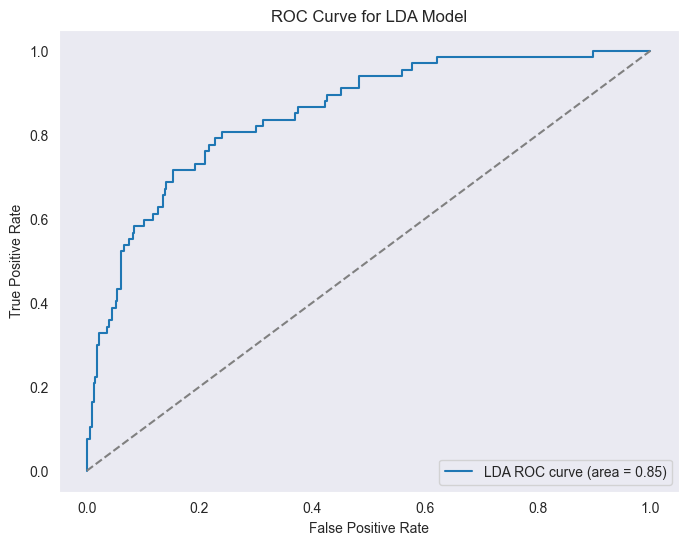

In [288]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming your classifier is 'lda' and you've trained it already
# Ensure that you extract the probability for the positive class.
# Check the order of classes:
print("Classes:", model.classes_)

# Find the index corresponding to 'high_bike_demand'
pos_index = list(model.classes_).index('high_bike_demand')
y_prob = model.predict_proba(X_test)[:, pos_index]

# Compute ROC curve, explicitly setting pos_label
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='high_bike_demand')
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LDA ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for LDA Model")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [289]:
train.columns

Index(['hour_of_day', 'day_of_week', 'month', 'holiday', 'weekday',
       'summertime', 'temp', 'dew', 'humidity', 'precip', 'snow', 'snowdepth',
       'windspeed', 'cloudcover', 'visibility', 'increase_stock'],
      dtype='object')

<h1>QDA</h1>

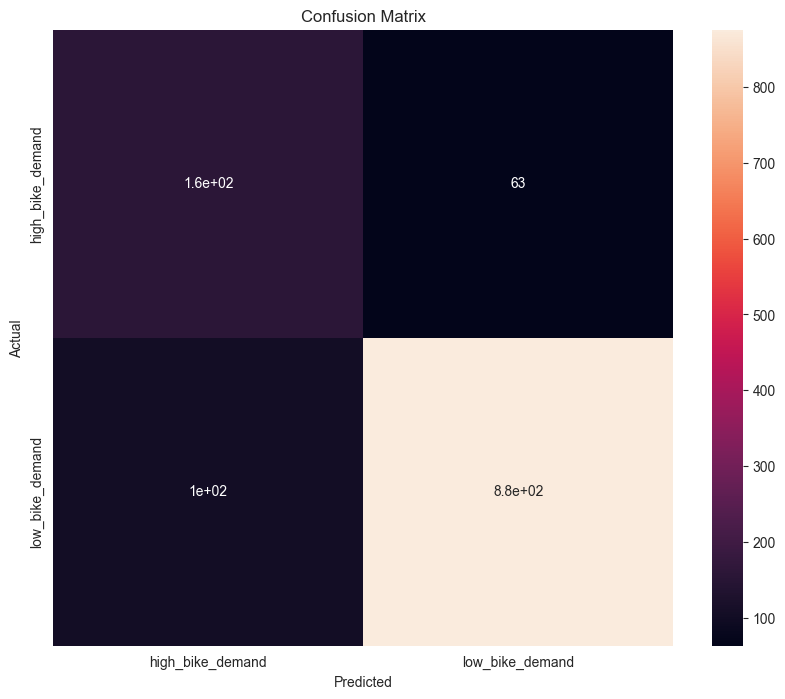

In [290]:
model=QuadraticDiscriminantAnalysis()
model.fit(X_train,y_train)
predictions=model.predict(X_test)
model.predict(X_test)
cm=pd.crosstab(y_train,model.predict(X_train))

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [291]:
predictions = model.predict(X_test)

correct_predictions=np.sum(y_test==model.predict(X_test))
accuracy=correct_predictions/len(y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.86


Classes: ['high_bike_demand' 'low_bike_demand']


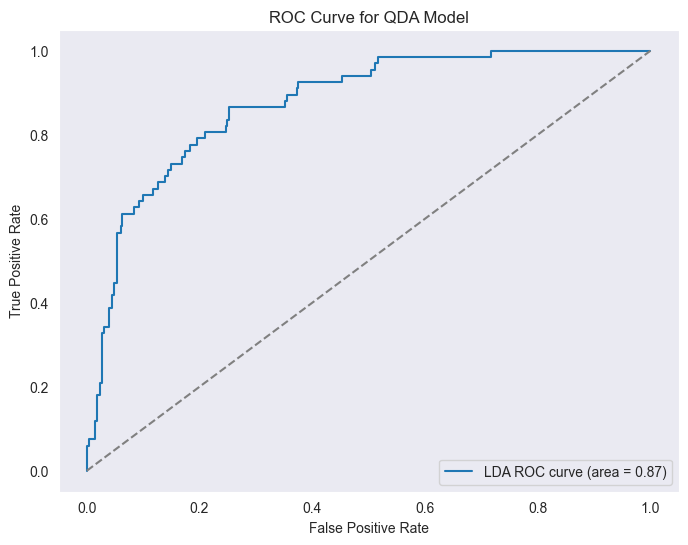

In [292]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming your classifier is 'lda' and you've trained it already
# Ensure that you extract the probability for the positive class.
# Check the order of classes:
print("Classes:", model.classes_)

# Find the index corresponding to 'high_bike_demand'
pos_index = list(model.classes_).index('high_bike_demand')
y_prob = model.predict_proba(X_test)[:, pos_index]

# Compute ROC curve, explicitly setting pos_label
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='high_bike_demand')
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LDA ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for QDA Model")
plt.legend(loc="lower right")
plt.grid()
plt.show()
